# NYC Auto Crash Risk: A Pricing-Style Frequency & Severity Study

**Question:** If you were pricing personal auto insurance in NYC, how much should crash risk differ by borough, time of day, and vehicle type, and how sure can you be?

**Approach (how actuaries price auto):**
1. **Frequency:** how often crashes happen per unit of exposure (registered vehicles × time) → Poisson / Negative Binomial GLM
2. **Severity:** when a crash happens, how likely is someone hurt → logistic regression
3. **Rating relativities:** turn model coefficients into a table like "Brooklyn = 1.15× base"

**Data (all free, public):**
- NYC Open Data, *Motor Vehicle Collisions – Crashes* (`h9gi-nx95`), every police-reported crash
- NY Open Data, *Vehicle, Snowmobile, and Boat Registrations* (`w4pv-hbkt`), used for exposure (vehicles registered per borough)

---
**How to use this notebook:** the data-pulling and plumbing is done. Cells marked **✍️ YOUR TURN** are the parts an interviewer will ask you about: choices, interpretation, limitations. Do those yourself, in your own words.

Setup: `pip install pandas numpy statsmodels matplotlib requests jupyter`

In [1]:
import os, time
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

YEARS = [2023, 2024, 2025]          # full calendar years to study
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
CRASH_CSV = f"{DATA_DIR}/crashes_{YEARS[0]}_{YEARS[-1]}.csv"
REG_CSV = f"{DATA_DIR}/registrations_by_borough.csv"
# Your manual export from NYC Open Data (put it in the same folder as this notebook).
# If it's not found, the notebook downloads the data from the API instead.
MANUAL_EXPORT = "Motor_Vehicle_Collisions_-_Crashes_20260926.csv"

# Borough name in crash data  <->  county name in DMV data
BORO_COUNTY = {"BRONX": "BRONX", "BROOKLYN": "KINGS", "MANHATTAN": "NEW YORK",
               "QUEENS": "QUEENS", "STATEN ISLAND": "RICHMOND"}
pd.set_option("display.width", 140)

## Step 1: Pull the data
Downloads once and saves a CSV; later runs load the CSV. Expect roughly 90–100k crashes per year.

In [2]:
def socrata_pages(url, params, page=50000):
    """Page through a Socrata (NYC/NY Open Data) API endpoint."""
    out, offset = [], 0
    while True:
        p = dict(params, **{"$limit": page, "$offset": offset})
        r = requests.get(url, params=p, timeout=120)
        r.raise_for_status()
        rows = r.json()
        out.extend(rows)
        print(f"  fetched {len(out):,} rows")
        if len(rows) < page:
            return pd.DataFrame(out)
        offset += page
        time.sleep(0.5)

if os.path.exists(CRASH_CSV):
    crashes = pd.read_csv(CRASH_CSV, low_memory=False)
elif os.path.exists(MANUAL_EXPORT):
    crashes = pd.read_csv(MANUAL_EXPORT, low_memory=False)
    # Manual exports use "CRASH DATE"-style names; convert to the API's "crash_date" style
    crashes.columns = crashes.columns.str.strip().str.lower().str.replace(" ", "_")
    crashes = crashes.rename(columns=lambda c: c.replace("vehicle_type_code_", "vehicle_type_code"))
    crashes.to_csv(CRASH_CSV, index=False)
else:
    cols = ["collision_id", "crash_date", "crash_time", "borough", "zip_code", "on_street_name",
            "number_of_persons_injured", "number_of_persons_killed",
            "contributing_factor_vehicle_1", "vehicle_type_code1"]
    crashes = socrata_pages(
        "https://data.cityofnewyork.us/resource/h9gi-nx95.json",
        {"$select": ",".join(cols),
         "$where": f"crash_date >= '{YEARS[0]}-01-01T00:00:00' AND crash_date < '{YEARS[-1]+1}-01-01T00:00:00'",
         "$order": "collision_id"})
    crashes.to_csv(CRASH_CSV, index=False)

print(crashes.shape)
crashes.head()

(487914, 28)


,crash_date,crash_time,borough,zip_code,latitude,longitude,on_street_name,cross_street_name,off_street_name,number_of_persons_injured,...,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code3,vehicle_type_code4,vehicle_type_code5
0,01/01/2021,20:00,NaN,NaN,40.83398,-73.826350,BRUCKNER EXPRESSWAY,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,4491746,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
1,01/01/2021,5:28,NaN,NaN,40.68730,-73.973656,LAFAYETTE AVENUE,NaN,NaN,0.0,...,Unspecified,NaN,NaN,NaN,4441905,Sedan,Sedan,NaN,NaN,NaN
2,01/01/2021,6:00,NaN,NaN,NaN,NaN,WEST SHORE EXPRESSWAY,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,4382769,Sedan,NaN,NaN,NaN,NaN
3,01/01/2021,19:30,BRONX,10463.0,40.88270,-73.892730,SEDGWICK AVENUE,VANCORTLANDT AVENUE WEST,NaN,0.0,...,NaN,NaN,NaN,NaN,4380949,NaN,NaN,NaN,NaN,NaN
4,01/01/2021,7:40,BROOKLYN,11218.0,40.63791,-73.978640,CORTELYOU ROAD,MC DONALD AVENUE,NaN,0.0,...,Unspecified,NaN,NaN,NaN,4380940,Station Wagon/Sport Utility Vehicle,Taxi,NaN,NaN,NaN


In [3]:
# Exposure: registered vehicles per borough.
# Source: NYS DMV "Vehicle, Snowmobile, and Boat Registrations" (data.ny.gov, dataset w4pv-hbkt),
# pulled 09/27/2026 with these filters:
#   Record Type = VEH | County in the 5 NYC counties | Reg Expiration Date after 01/01/2026
# then grouped by County and counted. Total = 2,168,454.
# (Earlier version used Reg Expiration Date after 09/26/2026 and Body Type != TRLR: total 2,110,255.
#  Each borough's count was ~2.5-3.6% lower, so relativities barely change: a sensitivity check.)
reg = pd.DataFrame({
    "county":   ["BRONX", "KINGS", "NEW YORK", "QUEENS", "RICHMOND"],
    "vehicles": [270_311, 535_834, 237_645, 828_994, 295_670],
})
reg["borough"] = reg["county"].map({v: k for k, v in BORO_COUNTY.items()})
assert reg["vehicles"].sum() == 2_168_454
reg

,county,vehicles,borough
0,BRONX,270311,BRONX
1,KINGS,535834,BROOKLYN
2,NEW YORK,237645,MANHATTAN
3,QUEENS,828994,QUEENS
4,RICHMOND,295670,STATEN ISLAND


## Step 2: Clean
A large share of crash records have **no borough**. Before dropping them, find out *which* crashes those are.

In [4]:
df = crashes.copy()
df["crash_date"] = pd.to_datetime(df["crash_date"])
df["year"] = df["crash_date"].dt.year
df = df[df["year"].isin(YEARS)].copy()   # keep only the study years
df["hour"] = pd.to_numeric(df["crash_time"].astype(str).str.split(":").str[0], errors="coerce")
for c in ["number_of_persons_injured", "number_of_persons_killed"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
df["injury"] = ((df["number_of_persons_injured"] + df["number_of_persons_killed"]) > 0).astype(int)
df["daytype"] = np.where(df["crash_date"].dt.dayofweek >= 5, "weekend", "weekday")

# Hour bands (hours in each band are used for exposure later)
BANDS = [("night", range(0, 6)), ("am_rush", range(6, 10)), ("midday", range(10, 16)),
         ("pm_rush", range(16, 20)), ("evening", range(20, 24))]
BAND_HOURS = {b: len(h) for b, h in BANDS}
df["hour_band"] = df["hour"].map({h: b for b, hs in BANDS for h in hs})

missing = df["borough"].isna()
print(f"Missing borough: {missing.mean():.1%} of crashes")
print("\nMost common streets among missing-borough crashes:")
print(df.loc[missing, "on_street_name"].str.strip().str.upper().value_counts().head(10))
print(f"\nInjury rate, missing borough: {df.loc[missing,'injury'].mean():.1%}  vs  known: {df.loc[~missing,'injury'].mean():.1%}")

Missing borough: 27.1% of crashes

Most common streets among missing-borough crashes:
on_street_name
BELT PARKWAY                  3690
BROOKLYN QUEENS EXPRESSWAY    2471
LONG ISLAND EXPRESSWAY        2457
GRAND CENTRAL PKWY            1843
FDR DRIVE                     1808
CROSS ISLAND PARKWAY          1454
MAJOR DEEGAN EXPRESSWAY       1371
VAN WYCK EXPWY                1174
HENRY HUDSON PARKWAY          1097
CROSS BRONX EXPY              1029
Name: count, dtype: int64

Injury rate, missing borough: 45.8%  vs  known: 42.2%


About 27% of crashes do not have a borough assigned to them. They are mostly on highways, plus a few neighborhoods where borough wasn't recorded. Missing borough records a slightly higher percentage of injury rate where 45.8%  vs  known: 42.2%. Dropping them would limit the model to street crashes and possibly understate boroughs where residents may have higher highway mileage like Queens. Since insurers rate by where a car is garaged rather than where it crashes, I allocated these crashes to boroughs in proportion to registered vehicles. This lowered Brooklyn's relativity from 1.93× to 1.62× Queens, so I report a range (1.6–1.9×) rather than a single number. The share of crashes missing a borough also fell from 32% in 2023 to 20% in 2025, which suggests a change in how crashes are recorded.

In [5]:
hwy = df[df["borough"].isna()].dropna(subset=["hour_band"]).copy()
df = df[df["borough"].isin(BORO_COUNTY)].dropna(subset=["hour_band"]).copy()

# Group messy vehicle-type strings into a few rating classes
def vehicle_group(v):
    v = str(v).lower()
    if any(k in v for k in ["bike", "bicycle", "scooter", "moped"]): return "bike_scooter"
    if "motorcycle" in v or "motorbike" in v: return "motorcycle"
    if any(k in v for k in ["truck", "van", "bus", "tractor", "dump", "tow"]): return "truck_bus_van"
    if "taxi" in v or "livery" in v: return "taxi"
    if any(k in v for k in ["sedan", "sport utility", "station wagon", "suv", "passenger", "4 dr", "2 dr"]): return "car_suv"
    return "other_unknown"
df["veh_group"] = df["vehicle_type_code1"].map(vehicle_group)

top = df["contributing_factor_vehicle_1"].value_counts().index[:8]
df["factor"] = df["contributing_factor_vehicle_1"].where(df["contributing_factor_vehicle_1"].isin(top), "Other")

print(df["veh_group"].value_counts(normalize=True).round(3))
print(df.shape)

veh_group
car_suv          0.789
truck_bus_van    0.077
other_unknown    0.047
bike_scooter     0.047
taxi             0.030
motorcycle       0.010
Name: proportion, dtype: float64
(199476, 35)


In [6]:
share = reg.set_index("borough")["vehicles"] / reg["vehicles"].sum()

miss_cells = (hwy.groupby(["year", "hour_band", "daytype"])
                .size()
                .rename("missing_crashes")
                .reset_index())
print(len(hwy), "highway crashes saved")
print(len(miss_cells), "rows")
print(miss_cells["missing_crashes"].sum(), "total")

73993 highway crashes saved
30 rows
73993 total


In [7]:
# How has the share of crashes with no borough changed over time?
by_year = pd.DataFrame({
    "all_crashes": pd.concat([df, hwy]).groupby("year").size(),
    "missing_borough": hwy.groupby("year").size(),
})
by_year["share_missing"] = (by_year["missing_borough"] / by_year["all_crashes"]).round(3)
by_year

,all_crashes,missing_borough,share_missing
year,,,
2023,96607,30877,0.320
2024,91316,26085,0.286
2025,85546,17031,0.199


## Step 3: Look before modeling

,avg_crashes_per_year,vehicles,crashes_per_1000_vehicles,injury_rate
borough,,,,
MANHATTAN,12318.333,237645,51.835,0.407
BROOKLYN,23326.000,535834,43.532,0.435
BRONX,10265.333,270311,37.976,0.428
QUEENS,17849.667,828994,21.532,0.420
STATEN ISLAND,2732.667,295670,9.242,0.372


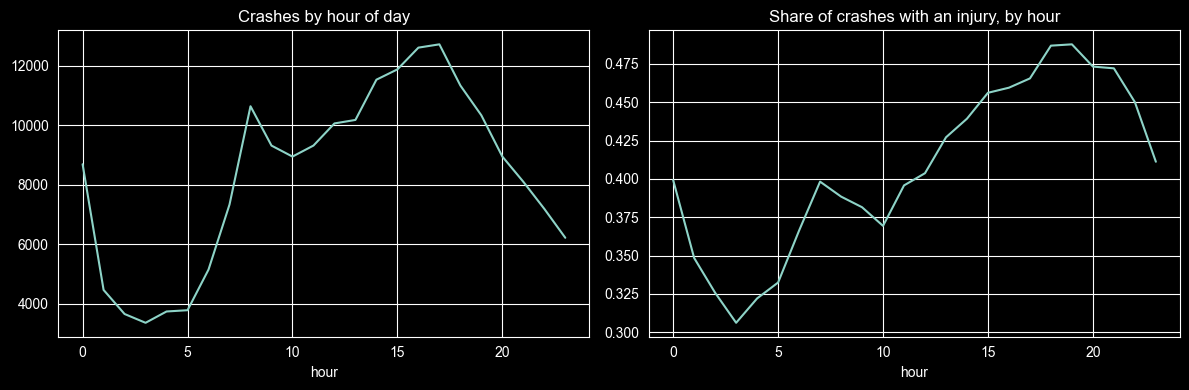

In [8]:
yearly = df.groupby(["borough", "year"]).size().rename("crashes").reset_index()
by_boro = (yearly.groupby("borough")["crashes"].mean().to_frame("avg_crashes_per_year")
           .join(reg.set_index("borough")["vehicles"]))
by_boro["crashes_per_1000_vehicles"] = 1000 * by_boro["avg_crashes_per_year"] / by_boro["vehicles"]
by_boro["injury_rate"] = df.groupby("borough")["injury"].mean()
display(by_boro.sort_values("crashes_per_1000_vehicles", ascending=False).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("hour").size().plot(ax=ax[0], title="Crashes by hour of day")
df.groupby("hour")["injury"].mean().plot(ax=ax[1], title="Share of crashes with an injury, by hour")
plt.tight_layout(); plt.show()

Manhattan has the highest crash rate, 53.6 crashes per 1,000 registered vehicles compared with 22.1 in Queens. This is largely a mismatch between the two numbers: the crash count includes every crash that happens in Manhattan, while the vehicle count only includes cars registered there, which is the fewest of any borough (about 11% of the city's total). Many of the cars driving in Manhattan are registered in other boroughs or states, and taxis, ride-share cars and delivery trucks are often registered elsewhere too. This overstates Manhattan's crash rate and understates the boroughs where those vehicles are registered. An insurer avoids this by assigning claims to the car's garaging address, but this dataset only records where crashes happen, so I treat Manhattan's result as an upper bound rather than a true rating factor. This is the same underlying issue as the highway crashes: crash location vs. garaging location.

## Step 4: Frequency model (Poisson → Negative Binomial GLM)

Each row = one borough × year × hour band × day type. The **offset** is log(exposure), where exposure = vehicles × days × share of day in the band. The model then estimates crash *rates*, not raw counts. This is exactly how auto frequency is modeled in practice.

In [9]:
cells = df.groupby(["borough", "year", "hour_band", "daytype"]).size().rename("crashes").reset_index()

# Number of weekdays / weekend days in each year
days = pd.DataFrame([{"year": y, "daytype": ("weekend" if d.dayofweek >= 5 else "weekday")}
                     for y in YEARS for d in pd.date_range(f"{y}-01-01", f"{y}-12-31")])
days = days.value_counts().rename("n_days").reset_index()

cells = (cells.merge(days, on=["year", "daytype"])
              .merge(reg[["borough", "vehicles"]], on="borough"))
before = cells["crashes"].sum()
cells = cells.merge(miss_cells, on=["year", "hour_band", "daytype"], how="left")
cells["crashes"] = cells["crashes"] + cells["missing_crashes"].fillna(0) * cells["borough"].map(share)
print(f"Crashes before: {before:,.0f}   after: {cells['crashes'].sum():,.0f}")
cells["exposure"] = cells["vehicles"] * cells["n_days"] * cells["hour_band"].map(BAND_HOURS) / 24
cells["log_exp"] = np.log(cells["exposure"])

formula = ("crashes ~ C(borough, Treatment('QUEENS')) + C(hour_band, Treatment('midday'))"
           " + C(daytype) + C(year)")
pois = smf.glm(formula, data=cells, offset=cells["log_exp"], family=sm.families.Poisson()).fit()
dispersion = pois.pearson_chi2 / pois.df_resid
print(f"Poisson dispersion (Pearson chi2 / df): {dispersion:.1f}  (≈1 is fine; much >1 = overdispersed)")

Crashes before: 199,476   after: 273,469
Poisson dispersion (Pearson chi2 / df): 69.6  (≈1 is fine; much >1 = overdispersed)


In [10]:
# Overdispersed? Refit as Negative Binomial. Estimate alpha from the Poisson fit (NB2 auxiliary regression).
mu = pois.fittedvalues
alpha = max(((cells["crashes"] - mu) ** 2 - cells["crashes"]).sum() / (mu ** 2).sum(), 1e-6)
nb = smf.glm(formula, data=cells, offset=cells["log_exp"],
             family=sm.families.NegativeBinomial(alpha=alpha)).fit()
print(f"alpha = {alpha:.4f}  |  AIC  Poisson {pois.aic:,.0f}  vs  NB {nb.aic:,.0f}")

def relativities(model):
    t = pd.DataFrame({"relativity": np.exp(model.params),
                      "low_95": np.exp(model.conf_int()[0]),
                      "high_95": np.exp(model.conf_int()[1]),
                      "p_value": model.pvalues})
    t = t.drop(index="Intercept")
    # "C(borough, Treatment('QUEENS'))[T.BRONX]"  ->  "borough: BRONX"
    t.index = t.index.str.replace(r"C\((\w+).*\)\[T\.(.+)\]", r"\1: \2", regex=True)
    return t.round(3)

freq_rel = relativities(nb)
freq_rel

alpha = 0.0178  |  AIC  Poisson 10,599  vs  NB 2,257


,relativity,low_95,high_95,p_value
borough: BRONX,1.477,1.378,1.582,0.000
borough: BROOKLYN,1.620,1.513,1.735,0.000
borough: MANHATTAN,1.874,1.749,2.008,0.000
borough: STATEN ISLAND,0.611,0.569,0.655,0.000
hour_band: am_rush,0.764,0.713,0.819,0.000
hour_band: evening,0.833,0.778,0.893,0.000
hour_band: night,0.589,0.550,0.631,0.000
hour_band: pm_rush,1.146,1.069,1.227,0.000
daytype: weekend,0.956,0.915,0.999,0.044
year: 2024,0.931,0.882,0.982,0.009


### Sensitivity checks
1. **Poisson vs. Negative Binomial:** same kind of multipliers, but compare how wide the confidence intervals are.
2. **Highway crashes dropped vs. allocated (Version B):** how much do the borough relativities depend on that choice?

In [11]:
# 1. Poisson vs Negative Binomial: similar relativities, different interval widths
compare = relativities(pois)[["relativity", "low_95", "high_95"]].join(
    relativities(nb)[["relativity", "low_95", "high_95"]], lsuffix="_pois", rsuffix="_nb")
compare["width_pois"] = compare["high_95_pois"] - compare["low_95_pois"]
compare["width_nb"] = compare["high_95_nb"] - compare["low_95_nb"]
print("Poisson vs Negative Binomial")
print(compare.round(3))

# 2. Refit with highway crashes DROPPED (known-borough crashes only), to compare with Version B
cells_dropped = cells.copy()
cells_dropped["crashes"] = cells_dropped["crashes"] - cells_dropped["missing_crashes"].fillna(0) * cells_dropped["borough"].map(share)
pois_d = smf.glm(formula, data=cells_dropped, offset=cells_dropped["log_exp"], family=sm.families.Poisson()).fit()
mu_d = pois_d.fittedvalues
alpha_d = max(((cells_dropped["crashes"] - mu_d) ** 2 - cells_dropped["crashes"]).sum() / (mu_d ** 2).sum(), 1e-6)
nb_d = smf.glm(formula, data=cells_dropped, offset=cells_dropped["log_exp"],
               family=sm.families.NegativeBinomial(alpha=alpha_d)).fit()
boro = [r for r in relativities(nb).index if r.startswith("borough")]
sens = pd.DataFrame({"highway_dropped": relativities(nb_d).loc[boro, "relativity"],
                     "version_B_allocated": relativities(nb).loc[boro, "relativity"]})
print("\nBorough relativities vs Queens: highway crashes dropped vs allocated by vehicle share")
print(sens)

Poisson vs Negative Binomial
                        relativity_pois  low_95_pois  high_95_pois  relativity_nb  low_95_nb  high_95_nb  width_pois  width_nb
borough: BRONX                    1.500        1.482         1.518          1.477      1.378       1.582       0.036     0.204
borough: BROOKLYN                 1.669        1.653         1.685          1.620      1.513       1.735       0.032     0.222
borough: MANHATTAN                1.921        1.899         1.943          1.874      1.749       2.008       0.044     0.259
borough: STATEN ISLAND            0.627        0.617         0.637          0.611      0.569       0.655       0.020     0.086
hour_band: am_rush                0.817        0.808         0.827          0.764      0.713       0.819       0.019     0.106
hour_band: evening                0.767        0.758         0.776          0.833      0.778       0.893       0.018     0.115
hour_band: night                  0.485        0.480         0.491          0.589 

### Severity by time of day
The frequency model shows *how often* crashes happen. This table shows *how bad* they are when they do, using all 2023–2025 crashes (including the highway crashes with no borough).

In [12]:
all_crashes = pd.concat([df, hwy])   # known-borough + highway crashes together

night = all_crashes.groupby("hour_band").agg(
    crashes=("injury", "size"),
    injury_rate=("injury", "mean"),
    deaths=("number_of_persons_killed", "sum"),
)
night["deaths_per_1000_crashes"] = 1000 * night["deaths"] / night["crashes"]
night.round(3)

,crashes,injury_rate,deaths,deaths_per_1000_crashes
hour_band,,,,
am_rush,45148,0.400,105.0,2.326
evening,42380,0.463,174.0,4.106
midday,82860,0.428,150.0,1.810
night,40216,0.375,220.0,5.470
pm_rush,62865,0.476,128.0,2.036


Using Queens as a relative comparison to other factors, this chart shows us how one factor is relative to Queens. A Brooklyn vehicle has about 1.62× the crash rate (95% range 1.51–1.74), the Bronx 1.48×, Manhattan 1.87×, and Staten Island 0.61×. All borough and hour-band ranges are far from 1.0, so those differences are real. The weekend effect (0.96, range 0.915–0.999) barely excludes 1.0; it's only about a 4% difference, too small to use in pricing. The year effects are statistically significant but likely reflect improved borough recording rather than a real decline. "Real" here means statistically real; the ranges don't account for data problems like crash location vs. garaging location.

Both models estimate the same kind of multipliers, so the relativities are similar for boroughs (Brooklyn 1.67 in Poisson vs. 1.62 in Negative Binomial) but differ more for hour bands (night 0.49 vs. 0.59). The difference is how much random variation each expects: Poisson assumes the variance equals the mean, but the dispersion check showed my data varies about 70× more than that. Poisson therefore understates uncertainty and gives confidence intervals that are too narrow. The Negative Binomial allows for this extra variation, gives more realistic intervals, and fits much better (AIC 2,257 vs. 10,599), so I trust the Negative Binomial results.

The night relativity of 0.59 means about 41% fewer crashes per hour than midday, but exposure counts all registered vehicles equally around the clock, and most cars aren't being driven at night. So this mostly reflects less traffic, not safer driving; without traffic-volume data I can't say whether night driving is riskier or safer per mile. Night crashes are actually less likely to cause an injury (37.5% vs. 42.8% at midday) but about three times as likely to be fatal (5.5 vs. 1.8 deaths per 1,000 crashes), consistent with higher speeds. Insurers only price on time of day through telematics programs that track when each car is actually driven.

## Step 5: Severity model: given a crash, what's the chance someone is hurt?

In [13]:
sev = smf.logit("injury ~ C(borough, Treatment('QUEENS')) + C(hour_band, Treatment('midday'))"
                " + C(daytype) + C(veh_group, Treatment('car_suv')) + C(factor, Treatment('Unspecified'))",
                data=df).fit(disp=0)
sev_or = relativities(sev).rename(columns={"relativity": "odds_ratio"})
sev_or.sort_values("odds_ratio", ascending=False)

,odds_ratio,low_95,high_95,p_value
veh_group: bike_scooter,11.463,10.745,12.228,0.000
factor: Failure to Yield Right-of-Way,5.669,5.434,5.914,0.000
veh_group: motorcycle,4.326,3.909,4.787,0.000
veh_group: taxi,2.058,1.948,2.174,0.000
factor: Other,1.925,1.874,1.977,0.000
veh_group: other_unknown,1.653,1.582,1.727,0.000
factor: Driver Inattention/Distraction,1.541,1.501,1.582,0.000
factor: Following Too Closely,1.490,1.419,1.565,0.000
hour_band: pm_rush,1.192,1.162,1.223,0.000
borough: BROOKLYN,1.114,1.087,1.141,0.000


Bikes/scooters and motorcycles have the highest injury odds: 88% of bike/scooter crashes and 73% of motorcycle crashes involve an injury, compared with 39% for cars and SUVs, giving odds ratios of about 11.5 and 4.3. Much of this is real: riders have no protection, so they are usually the person hurt. An odds ratio isn't a probability ratio, though; a bike crash is about 2.3 times as likely to involve an injury, not 11 times. The data also only includes police-reported crashes, and 42% of them involve an injury, far higher than in insurance claims data, because many minor car-only fender-benders are never reported. That inflates the car/SUV baseline, so the true injury odds ratios for bikes and motorcycles are likely even larger. The injury percentages describe reported crashes, not all crashes. The model also only uses the first vehicle listed, so some bike crashes may be labeled as car crashes.

## Step 6: Put it together: expected injury crashes per 1,000 vehicles by borough

Actuaries combine frequency × severity into a **pure premium**. We don't have claim dollars, so use *injury crashes per vehicle* as the loss measure.

In [14]:
combo = by_boro[["crashes_per_1000_vehicles", "injury_rate"]].copy()
combo["injury_crashes_per_1000_veh"] = combo["crashes_per_1000_vehicles"] * combo["injury_rate"]
base = combo.loc["QUEENS", "injury_crashes_per_1000_veh"]
combo["indicated_relativity_vs_queens"] = combo["injury_crashes_per_1000_veh"] / base
combo.round(3).sort_values("indicated_relativity_vs_queens", ascending=False)

,crashes_per_1000_vehicles,injury_rate,injury_crashes_per_1000_veh,indicated_relativity_vs_queens
borough,,,,
MANHATTAN,51.835,0.407,21.109,2.335
BROOKLYN,43.532,0.435,18.941,2.095
BRONX,37.976,0.428,16.260,1.799
QUEENS,21.532,0.420,9.039,1.000
STATEN ISLAND,9.242,0.372,3.442,0.381


Comparing my relativities with average full-coverage premiums (Insurify, August 2026), the results agree at the extremes of Staten Island (cheapest in both, 0.64× vs. 0.61× Queens) and the Bronx (among the highest in both). They disagree for Manhattan, which my model ranks riskiest but is among the cheapest to insure, and Queens, which my model ranks low but is among the most expensive. The main reason is garaging vs. crash location: insurers price by where a car is kept, so Manhattan's crashes by out-of-borough cars inflate my Manhattan result, while Queens drivers' crashes elsewhere deflate Queens. Premiums also reflect claim costs, not just crash counts: no-fault medical claims, fraud and litigation raise costs in some boroughs, full coverage includes theft, and my data only includes police-reported crashes. Crash frequency is only one piece of what drives insurance prices.

---
## Step 7: Write-up (1 page, your words)
1. **Question**: one sentence
2. **Data & exposure**: what you used, what you dropped and why
3. **Findings**: 3 bullets with numbers
4. **Limitations**: garaging vs. driving location; no traffic volume; police-reported only; no claim dollars
5. **What you'd do with insurer data**: real exposure (car-years, miles), claim severity in $, credibility weighting

**Be ready to answer:** Why Poisson for counts? What's an offset? What does overdispersion mean? Why not just use crash counts per borough?

1. Question

How much does car crash risk differ across NYC's five boroughs and across times of day, once you account for how many vehicles each borough has, and how close can public data get to the rating factors an insurer would use?

2. Data & exposure

I used NYC Open Data's police-reported crash records for 2023–2025 (273,469 crashes) and NYS DMV vehicle registrations (2,168,454 vehicles registered in the five boroughs, valid after 1/1/2026) as exposure. About 27% of crashes had no borough, almost all on highways. Rather than dropping them, I allocated them to boroughs using the percentage of registered cars attributed for each borough as an assumption, and compared that against dropping them as a sensitivity check. I modeled crash counts by borough, time of day, weekday/weekend and year with a Negative Binomial GLM, using registered vehicle-days (time when an accident is possible) as exposure.

3. Findings

Brooklyn vehicles have about 1.6× the crash rate of Queens (1.6–1.9× depending on how highway crashes are assigned); the Bronx about 1.5×; Staten Island about 0.6×.
The evening rush (4–8pm) is the riskiest time, about 1.15× midday. Night has 41% fewer crashes per hour, but night crashes are about 3× as likely to be fatal (5.5 vs. 1.8 deaths per 1,000 crashes).
Crash counts varied about 70× more than Poisson allows, so a Negative Binomial model was needed for honest confidence intervals.

4. Limitations

Crash location vs. garaging location. Insurers rate by where a car is kept, however this data records where crashes happen. This inflates Manhattan (1.9×, treated as an upper bound) because of higher activity, and it likely understates Queens in the same way.
No traffic volume: time-of-day results reflect how many cars are on the road, not risk per mile.
Police-reported crashes only: there could be a significant number of minor accidents that are not reported.
No claim dollars: this measures how often crashes happen, not what they cost.

5. What I'd do with insurer data

Use real exposure (car-years and miles driven), assign claims to the car's garaging address, model claim severity in dollars alongside frequency, add considerations for driver characteristics, and use credibility weighting so small groups lean on broader averages.